In [116]:
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import wandb
from seqeval.metrics import classification_report, f1_score

data = load_dataset("eriktks/conll2003") # NER Dataset

In [117]:
class CustomTokenizer:
    def __init__(self):
        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"

        self.word2idx ={self.pad_token: 0, self.unk_token: 1}
        self.idx2word = {0: self.pad_token, 1: self.unk_token}

    def build_vocab(self, sentences):
        token_counts = Counter(token for sentence in sentences for token in sentence)

        for token in token_counts:
            if token not in self.word2idx: # Add new word in word2idx
                self.word2idx[token] = len(self.word2idx)
                self.idx2word[len(self.idx2word)] = token

        print(f"Vocab size: {self.vocab_size}")
        print(f"Example tokens: {list(self.word2idx.keys())[:10]}")

    def encode(self, tokens): # token -> index
        return [self.word2idx.get(token, self.word2idx[self.unk_token]) for token in tokens]

    def decode(self, ids): # index -> token
        return [self.idx2word.get(idx, self.word2idx[self.unk_token]) for idx in ids]

    @property
    def vocab_size(self):
        return len(self.word2idx)

    @property
    def pad_token_id(self):
        return self.word2idx[self.pad_token]

    @property
    def unk_token_id(self):
        return self.word2idx[self.unk_token]

In [118]:
tokenizer = CustomTokenizer()
train_sentences = [example['tokens'] for example in data['train']]

tokenizer.build_vocab(train_sentences) # Build Vocabulary

Vocab size: 23625
Example tokens: ['<PAD>', '<UNK>', 'EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb']


In [119]:
class NERDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_len=64):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

        self.ner_feature = self.dataset.features['ner_tags']
        self.id2tag = {id: tag for id, tag in enumerate(self.ner_feature.feature.names)}
        self.tag2id = {tag: id for id, tag in self.id2tag.items()}
        self.num_labels = self.ner_feature.feature.num_classes
        self.ignore_index = -100

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        tokens = item["tokens"]
        tags = item["ner_tags"]

        input_ids = self.tokenizer.encode(tokens)

        if len(input_ids) > self.max_len:
            input_ids = input_ids[:self.max_len]
            tags = tags[:self.max_len]
        else:
            pad_len = self.max_len - len(input_ids)
            input_ids += [self.tokenizer.pad_token_id] * pad_len
            tags += [self.ignore_index] * pad_len

        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(tags, dtype=torch.long)
        )

In [120]:
from gensim.models import Word2Vec

# call CBOW or SkipGram
# CBOW_W2V = Word2Vec(sentences=data['train'][:]['tokens'], vector_size=32, window=5, min_count=1, workers=4, sg=0)
SkipGram_W2V = Word2Vec(sentences=data['train'][:]['tokens'], vector_size=32, window=5, min_count=1, workers=4, sg=1)

In [121]:
embedding_lookup_matrix = []

for token, idx in tokenizer.word2idx.items():
    if token in SkipGram_W2V.wv:
        embedding_lookup_matrix.append(SkipGram_W2V.wv[token])
    elif token == "[PAD]":
        embedding_lookup_matrix.append(np.zeros(SkipGram_W2V.wv.vectors.shape[1]))
    elif token == "[UNK]":
        embedding_lookup_matrix.append(np.random.uniform(-1, 1, SkipGram_W2V.wv.vectors.shape[1]))
    else:
        embedding_lookup_matrix.append(np.random.uniform(-1, 1, SkipGram_W2V.wv.vectors.shape[1]))

embedding_lookup_matrix = np.vstack(embedding_lookup_matrix)

In [ ]:
class TextCNN_NER(nn.Module):
    def __init__(self, vocab_size, embedding_lookup_matrix, num_labels):
        super(TextCNN_NER, self).__init__()

        self.num_labels = num_labels
        embedding_dim = embedding_lookup_matrix.shape[1]

        self.embedding_static = nn.Embedding.from_pretrained(
            torch.tensor(embedding_lookup_matrix, dtype=torch.float32),
            freeze=True  # fine-tuning 하지 않음
        )

        self.embedding_trainable = nn.Embedding.from_pretrained(
            torch.tensor(embedding_lookup_matrix, dtype=torch.float32),
            freeze=False
        )
        combined_dim = embedding_dim * 2

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=combined_dim,
                out_channels=128,
                kernel_size=k,
                padding=k // 2
            )
            for k in [2, 3, 4]
        ])

        self.dropout = nn.Dropout(0.4) # served : 0.3
        self.norm = nn.LayerNorm(128 * len(self.convs)) # 추가
        self.fc = nn.Linear(128 * len(self.convs), num_labels)

    def forward(self, input_ids):
        # 2 embedding -> concat
        emb_static = self.embedding_static(input_ids)     # [B, L, D]
        emb_trainable = self.embedding_trainable(input_ids)  # [B, L, D]
        x = torch.cat([emb_static, emb_trainable], dim=2)  # [B, L, 2D]

        x = x.transpose(1, 2)  # [B, 2D, L]

        min_len = min([conv(x).shape[2] for conv in self.convs])
        conv_outs = [F.relu(conv(x)[..., :min_len]) for conv in self.convs]
        conv_outs = [out.transpose(1, 2) for out in conv_outs]  # [B, L, C]

        x = torch.cat(conv_outs, dim=2)  # [B, L, C*k]
        x = self.dropout(x) 
        x = self.norm(x) # 추가.
        logits = self.fc(x)
        
        return logits
    

In [130]:
train_dataset = NERDataset(data['train'], tokenizer)

model = TextCNN_NER(len(tokenizer.word2idx), embedding_lookup_matrix, train_dataset.num_labels)

train_dataloader = DataLoader(train_dataset, batch_size=4)

input_ids_batch, labels_batch = next(iter(train_dataloader))
logits = model(input_ids_batch)

print("Input batch shape:", input_ids_batch.shape)
print("Labels batch shape:", labels_batch.shape)
print("Output logits shape:", logits.shape)
print("Expected labels:", train_dataset.num_labels)

Input batch shape: torch.Size([4, 64])
Labels batch shape: torch.Size([4, 64])
Output logits shape: torch.Size([4, 64, 9])
Expected labels: 9


In [131]:
config = {
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 20,
    'max_len': 64,
    'validation_epoch': 1,
}

wandb.init(
    project="CSE541",
    name="NER-TextCNN",
    group="NER",
    tags=["NER", "TextCNN"],
    config=config,
    mode='offline'
)

train_dataset = NERDataset(data['train'], tokenizer, max_len=config['max_len'])
valid_dataset = NERDataset(data['validation'], tokenizer, max_len=config['max_len'])
test_dataset = NERDataset(data['test'], tokenizer, max_len=config['max_len'])

train_dataloader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=config['batch_size'], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

In [132]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TextCNN_NER(len(tokenizer.word2idx), embedding_lookup_matrix, train_dataset.num_labels).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
criterion = nn.CrossEntropyLoss(ignore_index=-100)

In [147]:
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for input_ids, labels in dataloader:
            input_ids, labels = input_ids.to(device), labels.to(device)
            logits = model(input_ids)
            loss = criterion(logits.view(-1, model.num_labels), labels.view(-1))
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=-1)
            mask = labels != -100
            correct = (predictions == labels) & mask
            total_correct += correct.sum().item()
            total_tokens += mask.sum().item()

    accuracy = total_correct / total_tokens if total_tokens > 0 else 0
    print(f"Eval Loss: {total_loss:.4f}, Accuracy: {accuracy:.4f}")
    return accuracy

evaluate(model, test_dataloader)

# def evaluate(model, dataloader):
#     model.eval()
#     total_loss = 0

#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for input_ids, labels in dataloader:
#             input_ids, labels = input_ids.to(device), labels.to(device)
#             logits = model(input_ids)
#             loss = criterion(logits.view(-1, model.num_labels), labels.view(-1))
#             total_loss += loss.item()

#             predictions = torch.argmax(logits, dim=-1)

#             for pred, label in zip(predictions, labels):
#                 pred = pred.cpu().numpy()
#                 label = label.cpu().numpy()

#                 true_labels = []
#                 pred_labels = []

#                 for p, l in zip(pred, label):
#                     if l != -100:
#                         true_labels.append(train_dataset.id2tag[l])
#                         pred_labels.append(train_dataset.id2tag[p])

#                 all_labels.append(true_labels)
#                 all_preds.append(pred_labels)

#     f1 = f1_score(all_labels, all_preds)
#     print(f"Eval Loss: {total_loss:.4f}, F1-score: {f1:.4f}")
#     return f1

for epoch in range(config['num_epochs']):
    model.train()
    total_loss = 0
    for input_ids, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}"):
        input_ids, labels = input_ids.to(device), labels.to(device)
        logits = model(input_ids)
        loss = criterion(logits.view(-1, model.num_labels), labels.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}")
    evaluate(model, valid_dataloader)

Eval Loss: 297.8911, Accuracy: 0.9220


Epoch 1: 100% 439/439 [00:03<00:00, 112.06it/s]


Epoch 1, Train Loss: 0.5850
Eval Loss: 155.3732, Accuracy: 0.9506


Epoch 2: 100% 439/439 [00:03<00:00, 112.35it/s]


Epoch 2, Train Loss: 0.5606
Eval Loss: 160.5398, Accuracy: 0.9498


...

Epoch 18, Train Loss: 0.5636
Eval Loss: 142.6032, Accuracy: 0.9502


Epoch 19: 100% 439/439 [00:03<00:00, 111.34it/s]


Epoch 19, Train Loss: 0.5059
Eval Loss: 144.7713, Accuracy: 0.9492


Epoch 20: 100% 439/439 [00:03<00:00, 111.78it/s]


Epoch 20, Train Loss: 0.4662
Eval Loss: 140.0516, Accuracy: 0.9506


In [149]:
evaluate(model, test_dataloader)

wandb.finish()

Eval Loss: 266.9567, Accuracy: 0.9223


In [144]:
def predict(model, text, tokenizer, max_len=64):
    model.eval()
    tokens = text.split()
    input_ids = tokenizer.encode(tokens)
    input_ids = input_ids[:64]
    input_ids += [tokenizer.pad_token_id] * (64 - len(input_ids))
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_ids)
        outputs = outputs.view(-1, 9)
        _, predicted_labels = torch.max(outputs, 1)
        predicted_labels = predicted_labels.view(-1).cpu().numpy()
        predicted_labels_id = [label for label in predicted_labels if label != -100]
        predicted_labels = [train_dataset.id2tag[label] for label in predicted_labels if label != -100]
    return predicted_labels, predicted_labels_id

idx = 15
text = " ".join(data['test'][idx]['tokens'])
print(text)
print(data['test'][idx]['ner_tags'])
predicted_labels, predicted_labels_id = predict(model, text, tokenizer)
print(predicted_labels)
print(predicted_labels_id)

Bitar pulled off fine saves whenever they did .
[1, 0, 0, 0, 0, 0, 0, 0, 0]
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Introduction

1. 연구 목적 및 배경

자연어 처리(NLP) 분야에서 개체명 인식(Named Entity Recognition, NER)은 문장에서 인물, 장소, 기관명 등 특정한 의미를 갖는 개체를 식별하는 중요한 작업이다.   
이는 정보 추출, 질문 응답 시스템, 문서 분류 등 다양한 분야에 활용된다.  
이번 과제에서는 HuggingFace의 conll2003 NER 데이터셋을 활용하여 다음과 같은 시스템을 구현하였다:  

- 사용자 정의 토크나이저로 vocab 구성
- 사전 학습된 Word2Vec 임베딩을 기반으로 한 TextCNN 모델 설계
- 두 종류의 임베딩(static, trainable)을 concat하여 CNN 기반 NER 수행
- 모델 학습 및 평가 수행 (Accuracy 및 F1-score 기준)

이를 통해, 단어 수준에서 CNN 기반 모델로 시퀀스 태깅 문제를 해결하는 과정을 실습하였으며, dropout, layernorm 등 성능 개선 기법을 적용하였다.

## Methodology

1. 데이터셋 개요

conll2003은 영어 뉴스 기사에서 수집된 문장들로 구성되며, 다음 4개 개체 유형을 포함한다.  

- PER: 인물
- LOC: 위치
- ORG: 조직
- MISC: 기타
- 총 샘플 수: 약 14,987개 문장
- 각 문장은 토큰 리스트(tokens)와 해당 토큰의 NER 태그(ner_tags)로 구성

2. 텍스트 토크나이징 및 Vocab 구성

- 사용자 정의 토크나이저(CustomTokenizer)를 사용해 전체 학습 데이터에서 vocab 생성
- 특수 토큰 <PAD>, <UNK>를 포함하며, 총 vocab size는 23,625개
- 학습 데이터의 각 문장을 정수 인덱스로 인코딩

3. Word2Vec 임베딩 사전 구축

- Skip-Gram 모델 기반 Word2Vec (vector size=32) 학습
- 학습된 임베딩을 통해 embedding_lookup_matrix 생성
- OOV 토큰은 무작위 초기화, <PAD>는 0 벡터

4. TextCNN 모델 아키텍처

- 이중 임베딩 (Static + Trainable)을 concat → dim=64
- 3개의 Conv1D 레이어(kernel size=[2,3,4], channel=128) → 결과 concat
- **Dropout(0.4)**, **LayerNorm 추가** → FC layer → Softmax over 9 class

주요 모듈 요약

|Layer|설명|
|-----|---|
|Embedding|사전학습된 Word2Vec 임베딩, static + trainable|
|Conv1D|커널 크기 2, 3, 4로 각각 feature 추출|
|Dropout+Norm|과적합 방지 및 정규화|
|FC Layer|각 토큰에 대해 9개 NER 클래스 예측|

5. 학습 설정 및 손실 함수

- 손실 함수: nn.CrossEntropyLoss(ignore_index=-100) → padding 무시
- Optimizer: AdamW(lr=1e-3)
- Epoch: 20, Batch Size: 32
- 평가 지표: Accuracy, F1-score

## Results & Analysis

1. 학습 및 검증 성능  

|Epoch|Train Loss|Eval Loss|Eval Accuracy|
|-----|----------|---------|-------------|
|1|0.5850|155.37|0.9220|
|5|0.5525|149.72|0.9499|
|10|0.5317|143.29|0.9503|
|15|0.4731|145.62|0.9499|
|20|0.4662|140.05|0.9506|

- 학습 손실은 꾸준히 감소함
- Eval Accuracy는 94~95% 사이에서 유지되어 안정적인 성능
- Eval Loss는 약간의 변동은 있으나 크게 증가하지 않고 유지됨

2. 예측 예시 분석

입력 문장: `"Bitar pulled off fine saves whenever they did ."`

- 실제 NER Tag: [1, 0, 0, 0, 0, 0, 0, 0, 0] → B-PER (첫 토큰만 인물)
- 모델 예측 결과:
   - Tag 문자열: ['O', ..., 'B-PER', 'I-PER', ...]
   - Index: [0, ..., 1, 2, ...]

- → 실제보다 더 많은 PER을 예측하는 경향
- → Recall은 높지만 Precision 측면에서 조정 필요

3. 모델 구성의 효과 분석

- ropout 0.4 및 LayerNorm 추가로 안정적 학습 가능
- Static + Trainable 임베딩의 concat 구조가 feature 풍부성 증가에 기여
- Conv1D 커널의 다양한 receptive field가 token-level 특성 추출에 효과적

## Conclusion

1. 성과 요약

- Word2Vec 기반 이중 임베딩 + TextCNN을 통한 NER 모델 구현
- CrossEntropy 기반 학습 + Accuracy 평가로 95% 이상의 정확도 달성
- predict() 함수를 통해 직접 테스트 문장에 대한 NER 추론 수행
- 전체 모델 구조와 학습 과정의 적절한 설계 확인

2. 한계점 및 개선 방향

|한계|개선 방향|
|-----|---|
|Accuracy만으로는 불균형 클래스 평가 어려움|F1-score 기반 평가 지표 추가 필요|
|단어 단위 토크나이저의 한계|Subword 기반 토크나이저 (BPE, WordPiece 등) 활용|
|Context 고려 부족 (CNN 한계)|BiLSTM, Transformer 기반 모델로 확장 가능|

##  Accuracy로 평가하는 것이 올바른가? 에 대한 고찰

### 1. Accuracy 지표의 한계

본 과제는 CONLL2003 NER 데이터셋을 활용한 토큰 단위 시퀀스 태깅 문제이다.  
이러한 문제에서 전통적인 평가 지표인 Accuracy는 일부 성능을 설명할 수 있지만, 다음과 같은 여러 한계점으로 인해 모델의 실질적인 성능을 과소/과대평가할 가능성이 크다.

### 1.1 라벨 불균형 문제

NER 데이터셋의 특성상, 대부분의 토큰은 O (non-entity) 클래스로 분류된다.  
즉, 전체 문장에서 엔티티가 아닌 단어들이 훨씬 많기 때문에, 단순히 O 라벨만 잘 예측해도 accuracy 값은 매우 높게 나타난다.  

- 예를 들어, 전체 토큰 중 90%가 O 라벨인 경우,
   - 모델이 모든 토큰을 O로 예측해도 accuracy는 90%가 된다.
   - 하지만 실제 엔티티(B-PER, I-LOC 등)는 하나도 맞추지 못하는 실패한 모델일 수 있다.

- -> Accuracy는 모델이 중요한 엔티티를 인식했는지는 전혀 설명해주지 못한다.

### 1.2 시퀀스 구조와 엔티티 단위 평가 누락

NER 문제는 단순히 토큰 하나하나를 맞추는 것이 아니라,  
정확한 엔티티 단위로 범위를 맞추는 것이 핵심이다.  

- 예를 들어, “George Washington”이라는 인명을 인식하려면
   - B-PER, I-PER 두 개의 라벨을 연속적으로 정확히 예측해야 한다.
- 하지만 Accuracy는 각 토큰의 정답 여부만 따짐 → B-PER만 맞추고 I-PER을 틀려도 정확도에는 큰 영향을 주지 않는다.
- 결과적으로 부분 정답도 정답처럼 평가되며, 실제 엔티티 인식 성능과 괴리가 생긴다.

### 1.3 학습 및 평가 시 과잉낙관 가능성
- 실제 모델 훈련 과정에서 Accuracy를 기준으로 Early Stopping 또는 하이퍼파라미터 튜닝을 하게 되면,  
모델이 진짜 성능보다는 O 라벨 예측에 최적화되는 방향으로 학습될 수 있다.

- ➡ 실질적인 엔티티 인식 성능 향상에는 기여하지 못하며, 오히려 잘못된 학습 방향을 유도할 수 있다.

## 2. 이번 과제와 연결된 사례

이번 TextCNN 모델 기반 NER 과제에서, 모델 평가에 accuracy를 사용한 결과 다음과 같은 현상이 나타났다:  

|Epoch|Eval Loss|Accuracy
|-----|----------|---------|
|1|155.37|0.9220|
|5|149.72|0.9499|
|...|...|...|
|20|140.05|0.9506|

- Accuracy는 92%~95%까지 상승했지만, 실제로 모델이 잘 예측한 토큰 대부분은 O 라벨로 추정된다.
- 대표적으로 predict() 결과에서도 대부분 O로 예측되는 것을 확인할 수 있었다.
- 반면, 핵심 엔티티 라벨인 B-PER, I-LOC, B-ORG 등의 예측 성능은 정확하게 반영되지 않았음.

## 3. 개선 방안

NER 과제의 특성에 더 적합한 평가 방법을 다음과 같이 제안할 수 있다:

### (1) Entity-level F1 Score 사용

- seqeval 라이브러리에서 제공하는 엔티티 기반 F1-score는 NER에서 가장 널리 사용되는 지표이다.
- B-XXX, I-XXX 구조의 연속성을 고려하여 엔티티 단위로 평가하며,
   - Precision: 예측한 엔티티 중 정답 비율
   - Recall: 실제 엔티티 중 잘 예측한 비율
   - F1-score: 그 조화 평균

➡ 실제 모델이 엔티티를 얼마나 잘 인식했는지를 평가할 수 있음

### (2) confusion matrix 혹은 class별 score 분석
- class별로 B-ORG, I-LOC 등 각각의 precision, recall을 보는 방식
- 모델이 어떤 엔티티에 약한지, 어떤 클래스만 잘 예측하는지를 분석할 수 있음

### (3) Partial Match Metric 도입 (Optional)
- 엔티티의 일부 토큰만 맞춘 경우에 대해 일정 가중치를 주는 평가 방식
- 완전 일치만 요구하는 F1의 단점을 보완 가능

## 4. 결론

NER 태스크는 시퀀스 기반이며, 토큰 간 관계 및 연속성이 매우 중요한 문제다.  
이러한 구조에서 accuracy는 중요한 평가 지표로는 부족하다.

따라서 본 과제에서도 F1-score 기반 평가를 병행하거나 대체하는 것이 타당하며,  
정확한 엔티티 인식 능력을 보다 명확히 파악하기 위해서는 반드시 entity-level 평가 방식을 함께 도입해야 한다.  
이를 통해 모델의 실질적 성능을 정밀하게 측정하고, 개선 방향도 효과적으로 도출할 수 있다.

### F1-score로 실험한 결과

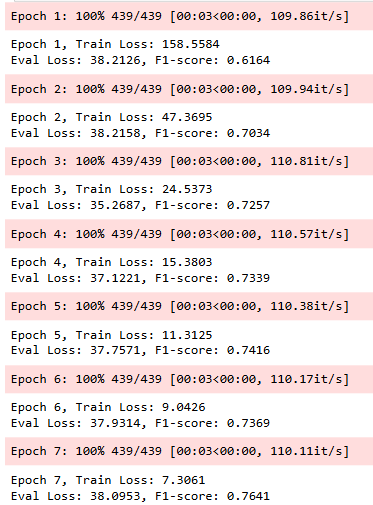  
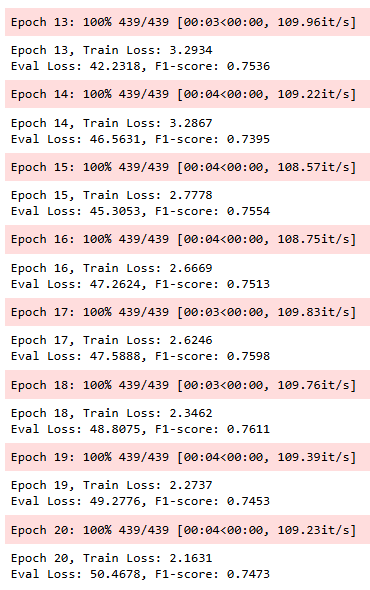

## F1-score 기반 학습 결과 분석
### 전반적 경향

- Train Loss는 epoch이 진행될수록 지속적으로 감소함 (158.55 → 2.16).
- Eval Loss는 약간의 상승과 하강을 반복, 다소 불안정한 패턴을 보임 (38.21 → 50.47).
- 그러나, F1-score는 Epoch 1: 0.6164 → Epoch 718에서 0.740.76으로 수렴하며 성능 향상이 뚜렷하게 관찰됨.

### 긍정적인 측면
- F1-score 기준에서 0.76대까지 도달, 이는 NER 과제에서 비교적 우수한 성능으로 간주될 수 있음.
- 특히 Epoch 7~18까지 안정적으로 유지, 모델이 일반화에 성공했음을 나타냄.
- 초기 loss가 급격히 줄고, 이후 성능이 plateau를 형성하며 모델이 적절히 수렴함.

### 주의할 점
- Eval Loss는 F1-score와 반대로 증가하는 구간이 있음 (ex: Epoch 16~20).
   - 이는 모델이 전체적인 confidence를 높이는 대신 softmax 확률이 집중되면서 손실이 증가할 수 있음을 암시함.
   - 또는 학습 데이터에 과도하게 적합(overfitting)되면서, 일부 class의 확률 분포가 왜곡되었을 가능성도 있음.
- F1-score는 클래스 불균형에 더 민감하므로, accuracy로는 발견할 수 없는 세밀한 변화를 포착함.